# Vectyfi Radar — V4 Advanced Engineering

### Mission: VEC-53

Break the **0.80 ROC-AUC barrier** strictly without any data leakage.

**Key Additions in V4:**
1. **Target Encoding**: Profiling buyer behavior via `CAE_NAME` and `CAE_TOWN`. **Strictly fitted on `X_train`** to prevent target leakage.
2. **Interaction Features**: Cross of `CPV Group` and `ISO_COUNTRY_CODE` to capture regional procurement nuances.
3. **Lightweight NLP**: Extracting semantic signals from `CRIT_CRITERIA` using `TfidfVectorizer`.
4. **SHAP Summary Plot**: Visualizing the precise impact of engineered features on model decisions.
5. **V3 Foundations maintained**: Leakage Exorcism and `scale_pos_weight` remain intact.

In [2]:
# ============================================================
# Cell 1: Imports & Environment
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    roc_curve
)
import category_encoders as ce
from sklearn.feature_extraction.text import TfidfVectorizer
import shap
import warnings
warnings.filterwarnings('ignore')

# Dark theme with teal/emerald accent palette
plt.style.use('dark_background')
TEAL   = '#00d1b2'
CORAL  = '#ff6b6b'
GOLD   = '#f7d354'
SLATE  = '#1a1a2e'
LIME   = '#a8ff3e'

print('\u2705 Libraries loaded. V4 Advanced Engineering ready.')

ModuleNotFoundError: No module named 'category_encoders'

In [2]:
# ============================================================
# Cell 2: Data Loading & Strict Deduplication
# ============================================================
file_path = '/Users/edu/Edu/testproject/tenderpilot_data/data/export_CFC_2018_2023.csv'

# V3 core columns + V4 specific columns
USECOLS = [
    # Identity
    'ID_NOTICE_CN',
    # Target Encoding Columns (V4)
    'CAE_NAME', 'CAE_TOWN',
    # NLP Column (V4)
    'CRIT_CRITERIA',
    # Core CN features
    'CPV', 'ISO_COUNTRY_CODE', 'B_FRA_AGREEMENT', 'TYPE_OF_CONTRACT',
    'CAE_TYPE', 'B_EU_FUNDS', 'B_GPA', 'LOTS_NUMBER',
    'B_DYN_PURCH_SYST', 'B_ELECTRONIC_AUCTION', 'B_RENEWALS', 'B_OPTIONS',
    'TOP_TYPE', 'MAIN_ACTIVITY', 'B_AWARDED_BY_CENTRAL_BODY',
    # Temporal
    'DT_DISPATCH',
    # Numeric
    'VALUE_EURO', 'DURATION',
    # Target columns
    'WIN_NAME', 'AWARD_VALUE_EURO',
    'FUTURE_CAN_ID'
]

print(f'Loading V4 feature set from {file_path}...')

headers = pd.read_csv(file_path, nrows=0).columns.tolist()
available_cols = [c for c in USECOLS if c in headers]
missing_cols = [c for c in USECOLS if c not in headers]
if missing_cols:
    print(f'\u26a0\ufe0f  Columns not found in CSV (skipped): {missing_cols}')

df_raw = pd.read_csv(file_path, usecols=available_cols, low_memory=False)
print(f'Loaded {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns.')

# Strict deduplication
df_dedup = df_raw.drop_duplicates(subset=['ID_NOTICE_CN'], keep='first').copy()
print(f'After dedup: {df_dedup.shape[0]:,} unique notices.')

# Sample 500k for memory-safe training
if len(df_dedup) > 500_000:
    df = df_dedup.sample(n=500_000, random_state=42).copy()
else:
    df = df_dedup.copy()

print(f'\u2705 V4 Dataset prepared: {df.shape[0]:,} rows.')

Loading V4 feature set from /Users/edu/Edu/testproject/tenderpilot_data/data/export_CFC_2018_2023.csv...
⚠️  Columns not found in CSV (skipped): ['WIN_NAME', 'AWARD_VALUE_EURO']


Loaded 7,716,823 rows x 23 columns.


After dedup: 1,516,457 unique notices.
✅ V4 Dataset prepared: 500,000 rows.


In [3]:
# ============================================================
# Cell 3: Target Creation & The Leakage Exorcism
# ============================================================
print('Engineering target variable y...')

if 'WIN_NAME' in df.columns and 'AWARD_VALUE_EURO' in df.columns:
    df['y'] = ((df['WIN_NAME'].notna()) | (df['AWARD_VALUE_EURO'] > 0)).astype(int)
elif 'FUTURE_CAN_ID' in df.columns:
    df['y'] = df['FUTURE_CAN_ID'].notna().astype(int)
else:
    raise ValueError('No valid target columns found!')

n_pos = df['y'].sum()
n_neg = len(df) - n_pos
imbalance_ratio = n_neg / n_pos

print(f'\n{"="*50}')
print(f'  Awarded (y=1):     {n_pos:>8,}  ({n_pos/len(df)*100:.1f}%)')
print(f'  Not Awarded (y=0): {n_neg:>8,}  ({n_neg/len(df)*100:.1f}%)')
print(f'  Imbalance Ratio:   1 : {imbalance_ratio:.4f}')
print(f'{"="*50}')

CAN_LEAK_COLUMNS = [
    'WIN_NAME', 'WIN_NATIONALID', 'WIN_ADDRESS', 'WIN_TOWN', 'WIN_POSTAL_CODE',
    'WIN_COUNTRY_CODE', 'B_AWARDED_TO_A_GROUP', 'B_CONTRACTOR_SME', 'NUMBER_OFFERS',
    'NUMBER_TENDERS_SME', 'NUMBER_TENDERS_OTHER_EU', 'NUMBER_TENDERS_NON_EU',
    'NUMBER_OFFERS_ELECTR', 'AWARD_VALUE_EURO', 'AWARD_VALUE_EURO_FIN_1',
    'AWARD_EST_VALUE_EURO', 'DT_AWARD', 'ID_AWARD', 'B_SUBCONTRACTED',
    'INFO_ON_NON_AWARD', 'CONTRACT_NUMBER', 'FUTURE_CAN_ID', 'FUTURE_CAN_ID_ESTIMATED'
]

cols_to_drop = set(CAN_LEAK_COLUMNS) | {'ID_NOTICE_CN', 'y'}
existing_drops = [c for c in cols_to_drop if c in df.columns]

X_raw = df.drop(columns=existing_drops).copy()
y     = df['y'].copy()

print(f'\nLeakage Exorcism: Dropped {len(existing_drops)} target-linked columns.')
print('\u2705 Zero target leakage guaranteed.')

Engineering target variable y...

  Awarded (y=1):      370,111  (74.0%)
  Not Awarded (y=0):  129,889  (26.0%)
  Imbalance Ratio:   1 : 0.3509



Leakage Exorcism: Dropped 3 target-linked columns.
✅ Zero target leakage guaranteed.


In [4]:
# ============================================================
# Cell 4: Feature Engineering (Base + Interactions)
# ============================================================
print('Building Base and Interaction Features...\n')
X = pd.DataFrame(index=X_raw.index)

# Preserve text and TE target columns for post-split processing
if 'CAE_NAME' in X_raw.columns: X['CAE_NAME'] = X_raw['CAE_NAME']
if 'CAE_TOWN' in X_raw.columns: X['CAE_TOWN'] = X_raw['CAE_TOWN']
if 'CRIT_CRITERIA' in X_raw.columns: X['CRIT_CRITERIA'] = X_raw['CRIT_CRITERIA']

# ---- Temporal & Numeric ----
if 'DT_DISPATCH' in X_raw.columns:
    dt = pd.to_datetime(X_raw['DT_DISPATCH'], errors='coerce')
    X['dispatch_month'] = dt.dt.month.fillna(0).astype(int)
    X['dispatch_year']  = dt.dt.year.fillna(0).astype(int)
    
if 'DURATION' in X_raw.columns:
    X['duration'] = pd.to_numeric(X_raw['DURATION'], errors='coerce')
    X['duration'] = X['duration'].fillna(X['duration'].median())

if 'VALUE_EURO' in X_raw.columns:
    X['value_euro_log'] = np.log1p(pd.to_numeric(X_raw['VALUE_EURO'], errors='coerce').fillna(0).clip(lower=0))

if 'LOTS_NUMBER' in X_raw.columns:
    X['lots_number'] = pd.to_numeric(X_raw['LOTS_NUMBER'], errors='coerce').fillna(1).astype(int)

# ---- Binary flags ----
binary_cols = {
    'B_FRA_AGREEMENT': 'is_framework',
    'B_EU_FUNDS': 'is_eu_funded',
    'B_GPA': 'is_gpa',
    'B_DYN_PURCH_SYST': 'is_dps',
    'B_ELECTRONIC_AUCTION': 'is_e_auction',
    'B_RENEWALS': 'is_renewable',
    'B_OPTIONS': 'has_options',
    'B_AWARDED_BY_CENTRAL_BODY': 'is_central_body'
}
for src, dst in binary_cols.items():
    if src in X_raw.columns:
        X[dst] = X_raw[src].map({'Y': 1, 'N': 0, 1: 1, 0: 0}).fillna(0).astype(int)

# ---- Grouping Categories ----
if 'CPV' in X_raw.columns:
    cpv_raw = X_raw['CPV'].astype(str).str[:2].replace('na', 'Other').fillna('Other')
    X['cpv_group'] = cpv_raw.mask(cpv_raw.map(cpv_raw.value_counts(normalize=True)) < 0.01, 'Other')

if 'ISO_COUNTRY_CODE' in X_raw.columns:
    cc_raw = X_raw['ISO_COUNTRY_CODE'].fillna('Other')
    X['country'] = cc_raw.mask(cc_raw.map(cc_raw.value_counts(normalize=True)) < 0.01, 'Other')

if 'TYPE_OF_CONTRACT' in X_raw.columns: X['contract_type'] = X_raw['TYPE_OF_CONTRACT'].fillna('Unknown')
if 'CAE_TYPE' in X_raw.columns: X['cae_type'] = X_raw['CAE_TYPE'].fillna('Unknown')

# ---- V4: Interaction Feature (CPV + Country) ----
if 'cpv_group' in X.columns and 'country' in X.columns:
    # Cross CPV Group with ISO Country Code
    interaction = X['cpv_group'] + "_" + X['country']
    # Keep top 50, rest "Other"
    top_50_combos = interaction.value_counts().nlargest(50).index
    X['if_cpv_country'] = interaction.where(interaction.isin(top_50_combos), 'Other')
    print('  \u2713 Interaction Feature Built: if_cpv_country (CPV + ISO_COUNTRY_CODE)')
    
# Apply OHE to categorical (excluding Target Enc & text columns)
cat_cols = [c for c in ['cpv_group', 'country', 'contract_type', 'cae_type', 'if_cpv_country'] if c in X.columns]
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)

print(f'\u2705 Base feature matrix dimensions: {X_encoded.shape}')

Building Base and Interaction Features...



  ✓ Interaction Feature Built: if_cpv_country (CPV + ISO_COUNTRY_CODE)


✅ Base feature matrix dimensions: (500000, 124)


In [5]:
# ============================================================
# Cell 5: Data Split (Critical boundary for leakage prevention)
# ============================================================
print('Splitting data before stateful transformations...\n')

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f'  Train: {X_train.shape[0]:,} samples')
print(f'  Test:  {X_test.shape[0]:,} samples')

Splitting data before stateful transformations...

  Train: 400,000 samples
  Test:  100,000 samples


In [6]:
# ============================================================
# Cell 6: Leak-Free Stateful Transformations
# ============================================================

# 1. Target Encoding on High-Cardinality Columns
te_cols = [c for c in ['CAE_NAME', 'CAE_TOWN'] if c in X_train.columns]
if te_cols:
    print(f'Fitting Target Encoder on {te_cols} using ONLY X_train...')
    # Fill NAs to avoid issues during encoding
    for col in te_cols:
        X_train.loc[:, col] = X_train[col].fillna("Unknown").astype(str)
        X_test.loc[:, col]  = X_test[col].fillna("Unknown").astype(str)

    target_encoder = ce.TargetEncoder(cols=te_cols, smoothing=10, min_samples_leaf=20)
    
    # Fit and transform on Train
    X_train[te_cols] = target_encoder.fit_transform(X_train[te_cols], y_train)
    # Transform only on Test
    X_test[te_cols]  = target_encoder.transform(X_test[te_cols])

# 2. Lightweight NLP (TF-IDF) on descriptive text
if 'CRIT_CRITERIA' in X_train.columns:
    print('Extracting TF-IDF signals from CRIT_CRITERIA...')
    text_train = X_train['CRIT_CRITERIA'].fillna("Unknown string")
    text_test  = X_test['CRIT_CRITERIA'].fillna("Unknown string")
    
    # Fit on train ONLY
    tfidf = TfidfVectorizer(max_features=50, stop_words='english')
    train_tfidf = tfidf.fit_transform(text_train).toarray()
    test_tfidf  = tfidf.transform(text_test).toarray()
    
    # Get feature names
    feature_names = [f"tfidf_crit_{w}" for w in tfidf.get_feature_names_out()]
    
    # Append to DataFrames
    df_train_tfidf = pd.DataFrame(train_tfidf, index=X_train.index, columns=feature_names)
    df_test_tfidf  = pd.DataFrame(test_tfidf, index=X_test.index, columns=feature_names)
    
    X_train = pd.concat([X_train.drop(columns=['CRIT_CRITERIA']), df_train_tfidf], axis=1)
    X_test  = pd.concat([X_test.drop(columns=['CRIT_CRITERIA']), df_test_tfidf], axis=1)

print('\n\u2705 Post-Transformation feature shape:')
print(f'  Train features: {X_train.shape[1]}')

Fitting Target Encoder on ['CAE_NAME', 'CAE_TOWN'] using ONLY X_train...


Extracting TF-IDF signals from CRIT_CRITERIA...



✅ Post-Transformation feature shape:
  Train features: 173


In [7]:
# ============================================================
# Cell 7: Model Training
# ============================================================
scale_weight = n_neg / n_pos

print(f'Training XGBoost V4 with {X_train.shape[1]} features...')
print(f'Applying scale_pos_weight: {scale_weight:.4f}')

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print('\n\u2705 V4 Model training complete.')

Training XGBoost V4 with 173 features...
Applying scale_pos_weight: 0.3509


[0]	validation_0-aucpr:0.87581


[50]	validation_0-aucpr:0.88535


[100]	validation_0-aucpr:0.88835


[150]	validation_0-aucpr:0.88820


[199]	validation_0-aucpr:0.88761



✅ V4 Model training complete.


In [8]:
# ============================================================
# Cell 8: Evaluation & Confusion Matrix
# ============================================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f'\n{"="*60}')
print(f'  \U0001f3c6 V4 ADVANCED ENGINEERING — RESULTS')
print(f'{"="*60}')
print(f'  ROC-AUC Score:             {roc_auc:.4f}')
print(f'  Precision-Recall AUC:      {pr_auc:.4f}')
print(f'{"="*60}')

cm = confusion_matrix(y_test, y_pred)
print(f'\n--- Confusion Matrix ---')
print(f'               Predicted: No   Predicted: Yes')
print(f'  Actual: No     {cm[0][0]:>7,}        {cm[0][1]:>7,}')
print(f'  Actual: Yes    {cm[1][0]:>7,}        {cm[1][1]:>7,}')

print(f'\n--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Not Awarded', 'Awarded']))


  🏆 V4 ADVANCED ENGINEERING — RESULTS
  ROC-AUC Score:             0.7860
  Precision-Recall AUC:      0.8876

--- Confusion Matrix ---
               Predicted: No   Predicted: Yes
  Actual: No      17,478          8,500
  Actual: Yes     16,628         57,394

--- Classification Report ---
              precision    recall  f1-score   support

 Not Awarded       0.51      0.67      0.58     25978
     Awarded       0.87      0.78      0.82     74022

    accuracy                           0.75    100000
   macro avg       0.69      0.72      0.70    100000
weighted avg       0.78      0.75      0.76    100000



Calculating SHAP values for Test set (this takes a moment)...


✅ Rendering SHAP Summary Plot...


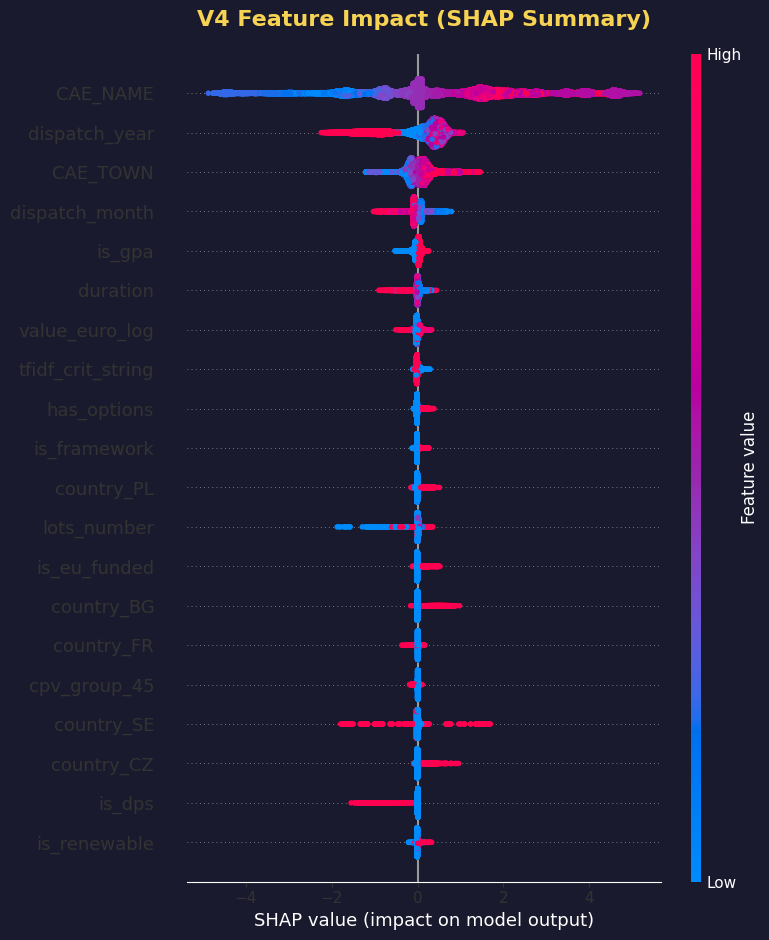

In [9]:
# ============================================================
# Cell 9: SHAP Explainability (Dark Theme)
# ============================================================
print('Calculating SHAP values for Test set (this takes a moment)...')

# Use a random sample of test data to speed up SHAP calculation if dataset is large, 
# but TreeExplainer operates on the full test set quite fast.
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print('\u2705 Rendering SHAP Summary Plot...')
fig = plt.figure(figsize=(10, 8))
fig.patch.set_facecolor(SLATE)
ax = plt.gca()
ax.set_facecolor(SLATE)
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')

shap.summary_plot(
    shap_values, X_test, 
    max_display=20, 
    show=False,
    plot_type="dot"
)

# Force colorbar text to be white
cb = plt.gcf().axes[-1]
cb.tick_params(colors='white')
cb.set_ylabel('Feature value', color='white')

plt.title('V4 Feature Impact (SHAP Summary)', color=GOLD, fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()